# Week 2 (follow-up) — Flagging Off-Topic AI Essays, and a Fair Evaluation

**Why this notebook exists:** `05_embeddings` found that many AI essays are **about something other than their `prompt_name`**: Churchill quotes, honesty, plastics, curfews… Several DAIGT-V2 generators were also given other essay prompts, and each essay was filed under the nearest of the 15 Persuade prompts. Human essays are all genuinely on-topic.

That makes **topic a free shortcut**: "this essay is about curfews → AI" is learnable and says nothing about AI *writing*. Every score so far is partly inflated by it.

**Decision (2026-10-04):** keep all the data and the existing splits, but
1. give every essay an **`on_topic`** flag, and
2. report every model on the **on-topic subset** as well: human vs AI essays written *about the same prompt*. That's the fair comparison.

The flag is used **only for evaluation**. No model ever sees it as a feature.

In [1]:
import sys
sys.path.append('..')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

from src.data import load_splits

SEED = 42
pd.set_option('display.width', 200)
HUMAN, AI = '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.6,
                     'axes.edgecolor': '#9a9a94', 'axes.titleweight': 'bold'})

# drop any flag from a previous run of this notebook: it is recomputed below
data = load_splits().drop(columns=['topic_sim', 'on_topic'], errors='ignore')
print(data.shape)

(44864, 8)


## Step 1 — Why the keyword check in `05` isn't good enough

`05` tested whether an essay contains its prompt's key word. That showed the problem exists, but it errs in both directions:
- **Too lenient:** a substring test for "car" also matches "**car**e", so essays about plastics or veganism counted as *Car-free cities*.
- **Too strict:** an essay can be on-topic without the exact word.

We need a measure of *what an essay is about* that uses all of its content words.

In [2]:
cf = data[(data['prompt_name'] == 'Car-free cities') & (data['label'] == 1)]
sneaky = cf[cf['text'].str.lower().str.contains('car') & ~cf['text'].str.lower().str.contains(r'\bcars?\b')]
print(f"'Car-free cities' AI essays that contain 'car' only inside other words: {len(sneaky)}")
for t in sneaky['text'].head(3):
    print('  ', repr(t[:120]))

'Car-free cities' AI essays that contain 'car' only inside other words: 160
   'In recent years, technology has had a profound impact on our daily lives and the world around us. From staying connected'
   'Single-use plastics have become a major concern for our environment. They are convenient to use, but their impact on the'
   'Climate change has become a pressing issue that needs to be addressed immediately. The effects of climate change are alr'


## Step 2 — Topic centres from human essays

Idea: **human essays define each prompt's topic**, because they were all written for that prompt.

1. **Content-word TF-IDF.** Same TF-IDF as `04`, but with English stop-words removed and single words only, so it reflects *subject matter* ("venus", "electoral", "phone") rather than style ("because", "additionally").
2. **Topic centre** of a prompt: the average TF-IDF vector of its human essays, re-normalised to length 1.
3. **Topic similarity** of an essay: the **cosine similarity** between the essay's vector and *its own prompt's* centre. TF-IDF rows already have length 1, so cosine is just the dot product.

The vectorizer is fitted on human essays from **all** splits, held-out prompts included, because each prompt's centre needs that prompt's human essays. That's fine here: this is an annotation of the data (like reading the prompt text), not a model being evaluated.

In [3]:
human = data['label'] == 0
topic_vec = TfidfVectorizer(stop_words='english', min_df=5, max_features=50_000, sublinear_tf=True)
topic_vec.fit(data.loc[human, 'text'])
X = topic_vec.transform(data['text'])

prompts = sorted(data['prompt_name'].unique())
centres = normalize(np.vstack([np.asarray(X[(human & (data['prompt_name'] == p)).values].mean(axis=0))
                               for p in prompts]))
sim_all = X @ centres.T                                   # essays x 15 prompts
own = data['prompt_name'].map({p: i for i, p in enumerate(prompts)}).values
data['raw_sim'] = sim_all[np.arange(len(data)), own]

print(f"vocabulary: {X.shape[1]:,} content words")
print("Top words of three topic centres (sanity check):")
names = topic_vec.get_feature_names_out()
for p in ['Exploring Venus', 'Seeking multiple opinions', 'Car-free cities']:
    print(f"  {p:28s}", ', '.join(names[np.argsort(centres[prompts.index(p)])[-10:][::-1]]))

vocabulary: 16,455 content words
Top words of three topic centres (sanity check):
  Exploring Venus              venus, planet, earth, author, surface, dangers, conditions, exploring, nasa, studying
  Seeking multiple opinions    advice, multiple, opinions, ask, asking, person, people, choice, different, opinion
  Car-free cities              car, cars, usage, pollution, smog, air, limiting, paris, driving, gas


The centres look right, so the method captures topic.

Some prompts are naturally more "focused" than others: Venus essays all share very specific vocabulary, while *Seeking multiple opinions* essays vary more. So a raw similarity of 0.25 means different things for different prompts. **Normalise per prompt:** divide by the *median* similarity of that prompt's human essays. Then 1.0 means "as on-topic as a typical human essay for this prompt", whatever the prompt.

In [4]:
human_median = data[human].groupby('prompt_name')['raw_sim'].median()
data['topic_sim'] = (data['raw_sim'] / data['prompt_name'].map(human_median)).round(4)
data.groupby('label')['topic_sim'].describe().round(3).rename(index={0: 'human', 1: 'AI'})

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
human,27371.0,0.988,0.181,0.193,0.874,1.0,1.111,1.677
AI,17493.0,0.549,0.302,0.006,0.273,0.5,0.825,1.444


## Step 3 — Choose the cut-off from the distribution

Plot relative topic similarity for each class. Each curve is normalised to area 1, because there are more human than AI essays.

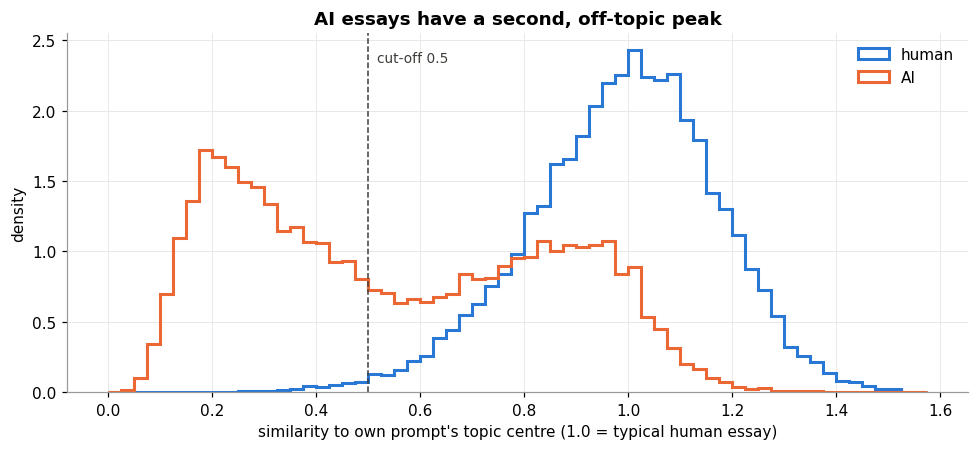

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.arange(0, 1.6, 0.025)
for lbl, color, name in [(0, HUMAN, 'human'), (1, AI, 'AI')]:
    ax.hist(data.loc[data['label'] == lbl, 'topic_sim'], bins=bins, density=True,
            histtype='step', linewidth=2, color=color, label=name)
ax.axvline(0.5, color='#3d3d3a', linewidth=1, linestyle='--')
ax.annotate('cut-off 0.5', (0.5, ax.get_ylim()[1] * 0.92), xytext=(6, 0), textcoords='offset points',
            fontsize=9, color='#3d3d3a')
ax.set_xlabel("similarity to own prompt's topic centre (1.0 = typical human essay)")
ax.set_ylabel('density')
ax.set_title('AI essays have a second, off-topic peak', fontsize=12)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('../images/06_topic_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

Human essays form one peak around 1.0. AI essays form **two**: an on-topic peak near 0.9, and an **off-topic peak around 0.2** (the Churchill/plastics/curfew essays). The valley between them is around 0.5, and only ~1% of human essays fall below 0.5.

**Rule: `on_topic = topic_sim >= 0.5`.** The valley isn't empty, so some essays near 0.5 are judgement calls. We read examples on both sides of the line, and later check that conclusions don't change if the cut-off moves to 0.4 or 0.6.

In [6]:
CUTOFF = 0.5
data['on_topic'] = data['topic_sim'] >= CUTOFF
print(f"human essays below the cut-off: {(~data.loc[human, 'on_topic']).mean() * 100:.1f}%")
print(f"AI essays flagged off-topic:     {(~data.loc[~human, 'on_topic']).sum():,} of {(~human).sum():,} "
      f"({(~data.loc[~human, 'on_topic']).mean() * 100:.1f}%)")

def show(d, n, title):
    print(f"\n===== {title} =====")
    for _, r in d.sample(n, random_state=SEED).iterrows():
        print(f"[sim={r['topic_sim']:.2f} | '{r['prompt_name']}' | {r['source']}]  {r['text'][:170]!r}")

ai = data[~human]
show(ai[ai['topic_sim'] < 0.3], 3, "AI, clearly off-topic (sim < 0.3)")
show(ai[(ai['topic_sim'] >= 0.4) & (ai['topic_sim'] < 0.5)], 4, "AI, just BELOW the cut-off (0.4-0.5)")
show(ai[(ai['topic_sim'] >= 0.5) & (ai['topic_sim'] < 0.6)], 4, "AI, just ABOVE the cut-off (0.5-0.6)")
show(data[human & ~data['on_topic']], 3, "HUMAN essays below the cut-off")

human essays below the cut-off: 0.9%
AI essays flagged off-topic:     8,747 of 17,493 (50.0%)

===== AI, clearly off-topic (sim < 0.3) =====
[sim=0.16 | 'Does the electoral college work?' | llama2_chat]  'Hey there!  So, you wanna know about Thomas Jefferson?  Like, he was like, super important in the history of America and stuff. \n\nOkay, so Jefferson was born in 1743 and '
[sim=0.29 | 'Facial action coding system' | mistral7binstruct_v1]  "Attitude refers to a person's perspective or outlook on something. It is a way of thinking or feeling towards something or someone, and it can greatly impact a person's l"
[sim=0.24 | 'Seeking multiple opinions' | mistral7binstruct_v2]  "Politics is a crucial aspect of society that affects every individual's life in one way or another. While some people may believe that politics is a good thing, others ar"

===== AI, just BELOW the cut-off (0.4-0.5) =====
[sim=0.46 | '"A Cowboy Who Rode the Waves"' | darragh_claude_v6]  'The Open Seas Await\n\nGro

Below 0.3 the essays are plainly about something else. **Near the cut-off it's genuinely mixed:** just *above* 0.5 there are still off-topic essays (graduating early, an after-school homework club), and just *below* it an on-topic Claude essay about the Seagoing Cowboys. So the flag is good but not perfect. 0.5 errs towards *keeping* some off-topic AI essays in the "on-topic" subset, which makes the on-topic scores slightly optimistic rather than pessimistic. Step 5 checks that the conclusions survive moving the cut-off to 0.4 or 0.6.

The few human essays below the line are low-quality or wandering (heavy misspellings, drifting off the question), not off-topic in the AI sense.

## Step 4 — Where are the off-topic essays?

In [7]:
by_source = (data[~human].groupby('source')['on_topic'].agg(['size', 'mean'])
             .rename(columns={'size': 'AI essays', 'mean': '% on-topic'}))
by_source['% on-topic'] = (by_source['% on-topic'] * 100).round(1)
print(by_source.sort_values('% on-topic'))

by_prompt = data.groupby(['prompt_name', 'label'])['on_topic'].mean().mul(100).round(1).unstack()
by_prompt.columns = ['% human on-topic', '% AI on-topic']
by_prompt['AI share, all'] = data.groupby('prompt_name')['label'].mean().round(3)
by_prompt['AI share, on-topic only'] = data[data['on_topic']].groupby('prompt_name')['label'].mean().round(3)
by_prompt.sort_values('% AI on-topic')

                                    AI essays  % on-topic
source                                                   
chat_gpt_moth                            2421        17.5
mistral7binstruct_v1                     2421        21.7
llama2_chat                              2420        26.6
mistral7binstruct_v2                     2419        27.2
falcon_180b_v1                           1055        45.2
llama_70b_v1                             1172        48.5
darragh_claude_v7                        1000        92.5
darragh_claude_v6                        1000        94.5
cohere-command                            350        99.1
mistralai/Mistral-7B-Instruct-v0.1        399        99.7
palm-text-bison1                          349        99.7
NousResearch/Llama-2-7b-chat-hf           400       100.0
kingki19_palm                            1384       100.0
radek_500                                 500       100.0
radekgpt4                                 200       100.0
train_essays  

,% human on-topic,% AI on-topic,"AI share, all","AI share, on-topic only"
prompt_name,,,,
Seeking multiple opinions,99.3,13.2,0.700,0.238
Summer projects,99.8,28.7,0.352,0.135
Facial action coding system,97.9,34.0,0.297,0.128
"""A Cowboy Who Rode the Waves""",98.1,39.9,0.276,0.134
Distance learning,99.9,41.1,0.611,0.393
Mandatory extracurricular activities,99.3,42.9,0.457,0.267
Phones and driving,99.8,49.2,0.262,0.149
Community service,99.4,50.0,0.263,0.152
Grades for extracurricular activities,99.3,61.6,0.232,0.158


In [8]:
by_split = data.groupby('split').apply(lambda d: pd.Series({
    'essays': len(d), 'on-topic essays': int(d['on_topic'].sum()),
    'AI on-topic': int((d['on_topic'] & (d['label'] == 1)).sum()),
    'AI share, on-topic': round(d.loc[d['on_topic'], 'label'].mean(), 3)}), include_groups=False)
by_split.loc[['train', 'val', 'test', 'heldout_prompt', 'heldout_generator']]

,essays,on-topic essays,AI on-topic,"AI share, on-topic"
split,,,,
train,28006.0,21953.0,3781.0,0.172
val,3501.0,2733.0,463.0,0.169
test,3501.0,2745.0,473.0,0.172
heldout_prompt,7135.0,6401.0,1981.0,0.309
heldout_generator,2721.0,2048.0,2048.0,1.000


- Off-topic essays come almost entirely from a few sources: `chat_gpt_moth`, `llama2_chat`, both `mistral7binstruct` sets (mostly off-topic), and `llama_70b_v1` / `falcon_180b_v1` (about half). The rest are almost all on-topic.
- The prompt imbalance **shrinks a lot** on the on-topic subset: *Seeking multiple opinions* goes from 70% AI to 24%, because it was a catch-all label. It doesn't vanish (on-topic AI share still ranges 13–40% by prompt), so a little topic signal remains.
- The on-topic AI share in train/val/test is ~17%, and **on-topic `test` has only 473 AI essays**. On-topic test scores therefore move by a point or two from a handful of essays, so read small differences as noise.

Save the flag. `src/data.py` now adds `topic_sim` and `on_topic` to `load_splits()` automatically.

In [9]:
data[['topic_sim', 'on_topic']].to_csv('../data/processed/on_topic.csv')
check = load_splits()
assert check['on_topic'].equals(data['on_topic'])
print("saved; load_splits() columns:", list(check.columns))

saved; load_splits() columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'n_words', 'dup_cluster', 'split', 'topic_sim', 'on_topic']


## Step 5 — Re-score Weeks 1–2 on the fair subset

The models from `04` and `05` were not saved, so refit them exactly as before (same features, same tuned `C`) and score each **twice** with `src/evaluate.py`: on all essays (should reproduce the earlier tables) and on **on-topic essays only**.

Prediction: models that lean on topic (prompt-only, averaged embeddings, especially GloVe) should lose the most; TF-IDF, which also sees style words, should lose less.

In [10]:
from gensim.models import KeyedVectors
from gensim.utils import simple_preprocess
import gensim.downloader as gensim_api
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from src.evaluate import evaluate, evaluate_on_topic, COLUMNS

data = load_splits()
train, test = data[data['split'] == 'train'], data[data['split'] == 'test']
ho_prompt, ho_gen = data[data['split'] == 'heldout_prompt'], data[data['split'] == 'heldout_generator']
rows_of = lambda d: data.index.get_indexer(d.index)
sets = (test, ho_prompt, ho_gen)

models = {}   # name -> (score_fn, threshold)

tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(train[['n_words']], train['label'])
models['length only (tree)'] = (lambda d: tree.predict_proba(d[['n_words']])[:, 1], 0.5)

ohe = OneHotEncoder(handle_unknown='ignore')
plr = LogisticRegression(max_iter=1000).fit(ohe.fit_transform(train[['prompt_name']]), train['label'])
models['prompt only'] = (lambda d: plr.predict_proba(ohe.transform(d[['prompt_name']]))[:, 1], 0.5)

t0 = time.time()
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=200_000, sublinear_tf=True)
X_tfidf = vec.fit(train['text']).transform(data['text'])
svm = LinearSVC(C=1).fit(X_tfidf[rows_of(train)], train['label'])
lr = LogisticRegression(C=10, max_iter=2000).fit(X_tfidf[rows_of(train)], train['label'])
models['TF-IDF + LogReg (C=10)'] = (lambda d: lr.predict_proba(X_tfidf[rows_of(d)])[:, 1], 0.5)
models['TF-IDF + LinearSVM (C=1)'] = (lambda d: svm.decision_function(X_tfidf[rows_of(d)]), 0.0)
print(f"TF-IDF models refit in {time.time() - t0:.0f}s")

TF-IDF models refit in 95s


In [11]:
t0 = time.time()
tokens = data['text'].map(lambda t: simple_preprocess(t, min_len=1, max_len=30)).tolist()
kvs = {'CBOW': KeyedVectors.load('../models/w2v_cbow.kv'),
       'Skip-gram': KeyedVectors.load('../models/w2v_skipgram.kv'),
       'GloVe': gensim_api.load('glove-wiki-gigaword-100')}
best_C = {'CBOW': 1, 'Skip-gram': 10, 'GloVe': 0.1}        # tuned on val in 05

def doc_vectors(kv, token_lists):
    out = np.zeros((len(token_lists), kv.vector_size), dtype=np.float32)
    for i, toks in enumerate(token_lists):
        known = [w for w in toks if w in kv.key_to_index]
        if known:
            out[i] = kv[known].mean(axis=0)
    return out

for name, kv in kvs.items():
    V = doc_vectors(kv, tokens)
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=best_C[name], max_iter=3000))
    clf.fit(V[rows_of(train)], train['label'])
    models[f'avg {name} + LogReg'] = (lambda d, clf=clf, V=V: clf.predict_proba(V[rows_of(d)])[:, 1], 0.5)
print(f"embedding models refit in {time.time() - t0:.0f}s")

embedding models refit in 273s


Score everything. `all` should match `results/04_baseline.csv` and `05_embeddings.csv` (embedding rows can differ slightly, since the saved Word2Vec vectors come from one particular multithreaded run).

In [12]:
all_rows = pd.DataFrame([evaluate(f, th, n, *sets) for n, (f, th) in models.items()])
fair_rows = pd.DataFrame([evaluate_on_topic(f, th, n, *sets) for n, (f, th) in models.items()])

key = ['test_f1', 'test_auc', 'heldout_prompt_f1', 'heldout_prompt_auc', 'heldout_gen_detection', 'heldout_gen_auc']
compare = pd.concat({'all essays': all_rows[key], 'on-topic only': fair_rows[key]}, axis=1)
compare.round(3)

all essays                                                                                     on-topic only                                                \
                            test_f1 test_auc heldout_prompt_f1 heldout_prompt_auc heldout_gen_detection heldout_gen_auc       test_f1 test_auc heldout_prompt_f1 heldout_prompt_auc   
length only (tree)            0.103    0.719             0.032              0.726                 0.002           0.750         0.037    0.674             0.003              0.700   
prompt only                   0.582    0.763             0.000              0.500                 0.204           0.513         0.315    0.686             0.000              0.500   
TF-IDF + LogReg (C=10)        0.991    1.000             0.913              0.990                 0.897           1.000         0.986    0.999             0.883              0.988   
TF-IDF + LinearSVM (C=1)      0.995    1.000             0.973              0.997                 0.909           1.000         0.994    1.000             0.965              0.997   
avg CBOW + LogReg             0.957    0.994             0.746              0.879                 0.890           0.985         0.912    0.992             0.658              0.841   
avg Skip-gram + LogReg        0.967    0.995             0.839              0.949                 0.838           0.980         0.942    0.995             0.787              0.935   
avg GloVe + LogReg            0.931    0.986             0.445              0.607                 0.879           0.977         0.869    0.981             0.234              0.484   

                                                                
                         heldout_gen_detection heldout_gen_auc  
length only (tree)                       0.001           0.759  
prompt only                              0.175           0.481  
TF-IDF + LogReg (C=10)                   0.865           0.999  
TF-IDF + LinearSVM (C=1)                 0.880           1.000  
avg CBOW + LogReg                        0.867           0.981  
avg Skip-gram + LogReg                   0.804           0.976  
avg GloVe + LogReg                       0.852           0.971

**Sensitivity to the cut-off.** If the conclusions only hold at exactly 0.5, they're fragile. Re-score the strongest and the weakest content-based models with the cut-off at 0.4 and 0.6.

In [13]:
sens = []
for cut in [0.4, 0.5, 0.6]:
    flagged = lambda d, cut=cut: d.assign(on_topic=d['topic_sim'] >= cut)
    for n in ['TF-IDF + LinearSVM (C=1)', 'avg GloVe + LogReg']:
        f, th = models[n]
        r = evaluate_on_topic(f, th, n, *(flagged(d) for d in sets))
        sens.append({'cut-off': cut, 'model': n, **r[['test_auc', 'heldout_prompt_auc', 'heldout_gen_detection']].round(3)})
pd.DataFrame(sens).set_index(['model', 'cut-off'])

,,test_auc,heldout_prompt_auc,heldout_gen_detection
model,cut-off,,,
TF-IDF + LinearSVM (C=1),0.4,1.000,0.997,0.888
avg GloVe + LogReg,0.4,0.983,0.521,0.857
TF-IDF + LinearSVM (C=1),0.5,1.000,0.997,0.880
avg GloVe + LogReg,0.5,0.981,0.484,0.852
TF-IDF + LinearSVM (C=1),0.6,1.000,0.997,0.861
avg GloVe + LogReg,0.6,0.980,0.468,0.834


## Step 6 — Save

In [14]:
fair_rows[COLUMNS].round(4).to_csv('../results/06_on_topic.csv')
print(open('../results/06_on_topic.csv').read())

,test_acc,test_precision,test_recall,test_f1,test_auc,heldout_prompt_f1,heldout_prompt_auc,heldout_gen_detection,heldout_gen_auc
length only (tree),0.831,1.0,0.019,0.0373,0.6744,0.003,0.7004,0.001,0.7594
prompt only,0.7439,0.2924,0.3425,0.3155,0.6863,0.0,0.5,0.1753,0.4813
TF-IDF + LogReg (C=10),0.9953,0.9936,0.9789,0.9862,0.9993,0.8827,0.9882,0.8647,0.9994
TF-IDF + LinearSVM (C=1),0.9978,1.0,0.9873,0.9936,0.9996,0.9651,0.9972,0.8799,0.9996
avg CBOW + LogReg,0.9698,0.9131,0.9112,0.9122,0.9915,0.6577,0.8409,0.8667,0.9813
avg Skip-gram + LogReg,0.98,0.9336,0.9514,0.9424,0.9951,0.7867,0.9351,0.8037,0.9763
avg GloVe + LogReg,0.9545,0.861,0.8774,0.8691,0.9808,0.2342,0.4844,0.8521,0.9715



## Key takeaways

- **Half of the AI essays (8,747 of 17,493) are off-topic** for their `prompt_name`, against 0.9% of human essays. They come almost entirely from six sources: `chat_gpt_moth` (only 18% on-topic), `mistral7binstruct_v1`/`_v2`, `llama2_chat`, and about half of `falcon_180b_v1` and `llama_70b_v1`. The flag (`on_topic`, `topic_sim`) is saved in `data/processed/on_topic.csv` and added by `load_splits()`.
- **TF-IDF does not depend on the topic shortcut.** On on-topic essays only, LinearSVM keeps test AUC 0.9996 and held-out-prompt AUC 0.997 (F1 0.965). It's genuinely picking up style, and the Week 1 baseline stands.
- **Averaged embeddings do depend on it.** On the fair subset, held-out-prompt AUC drops to 0.935 (Skip-gram), 0.841 (CBOW) and **0.484 for GloVe, which is no better than chance**. Averaged GloVe was mostly detecting "this essay is about something no human wrote about".
- **Unseen generators are a little harder when on-topic:** LinearSVM detection drops from 90.9% to 88.0%. The off-topic Falcon essays were the easy ones.
- **The prompt-only model falls** from test AUC 0.763 to 0.686 on the fair subset, confirming most of its "skill" was the off-topic essays.
- **Robust to the cut-off:** at 0.4, 0.5 and 0.6 the TF-IDF numbers barely move and GloVe stays at chance on unseen prompts.
- **From now on, report both rows for every model** (`evaluate` and `evaluate_on_topic` in `src/evaluate.py`). The on-topic held-out-prompt score is the headline "honest" number. On-topic `test` has only 473 AI essays, so differences of a point or two there are noise.
